# Multi-Frequency Roughness Measurement with Animated Simulation

Fringe projection profilometry measures surface topography by projecting sinusoidal
patterns onto a surface and analyzing the phase distortion caused by surface height
variations. The recovered phase is proportional to height, enabling non-contact 3D
surface roughness measurement at micrometer resolution.

This notebook compares two approaches:

1. **Single-frequency** -- one fringe period with spatial phase unwrapping. Spatial
   unwrapping propagates from pixel to pixel, so errors at step discontinuities
   spread across the entire surface, corrupting roughness measurements.

2. **Multi-frequency** -- three fringe periods (coarse to fine) with temporal phase
   unwrapping. Each pixel is unwrapped independently using the coarser frequency as
   a guide, making the method robust to discontinuities.

Three embedded animations illustrate the measurement process:
- **Animation 1**: Phase-shifting fringe projection (pattern + captured frame)
- **Animation 2**: Temporal unwrapping progression (coarse to fine)
- **Animation 3**: Rotating 3D roughness comparison

In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import Video
import imageio_ffmpeg

from micro_projection import SimulationSource, SimulationConfig, CalibrationParams
from micro_projection.patterns import generate_phase_sequence, compute_carrier_phase
from micro_projection.processing import (
    extract_phase, phase_to_height, remove_plane,
    separate_surface, compute_roughness_parameters,
    temporal_unwrap, generate_multifreq_patterns,
)
from micro_projection.core.datatypes import HeightMap, PhaseMap
from micro_projection.processing.unwrap import unwrap_phase
from multifreq_surfaces import (
    create_smooth_surface, create_simple_step_surface, create_complex_surface,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

## Parameters

In [2]:
RESOLUTION = (512, 512)
N_STEPS = 12
NOISE = 0.005
SINGLE_PERIOD = 16
MULTI_PERIODS = [256, 64, 16]   # coarse -> fine
CUTOFF = 50.0
FORM_METHOD = 'morphological'
SIMULATION_HEIGHT_SCALE = 50.0  # must match SimulationSource._compute_deformed_pattern
QUALITY_THRESHOLD = 0.5

## Test Surface

The complex surface consists of a known **form** (macro shape with steps, pillars,
and pits) and known **roughness** (micro-scale random texture). By decomposing the
surface into these two components, we can objectively measure how accurately each
method recovers the roughness after form removal.

The complex surface features multiple step discontinuities at different heights,
a raised pillar, and a recessed pit -- all designed to challenge spatial unwrapping.

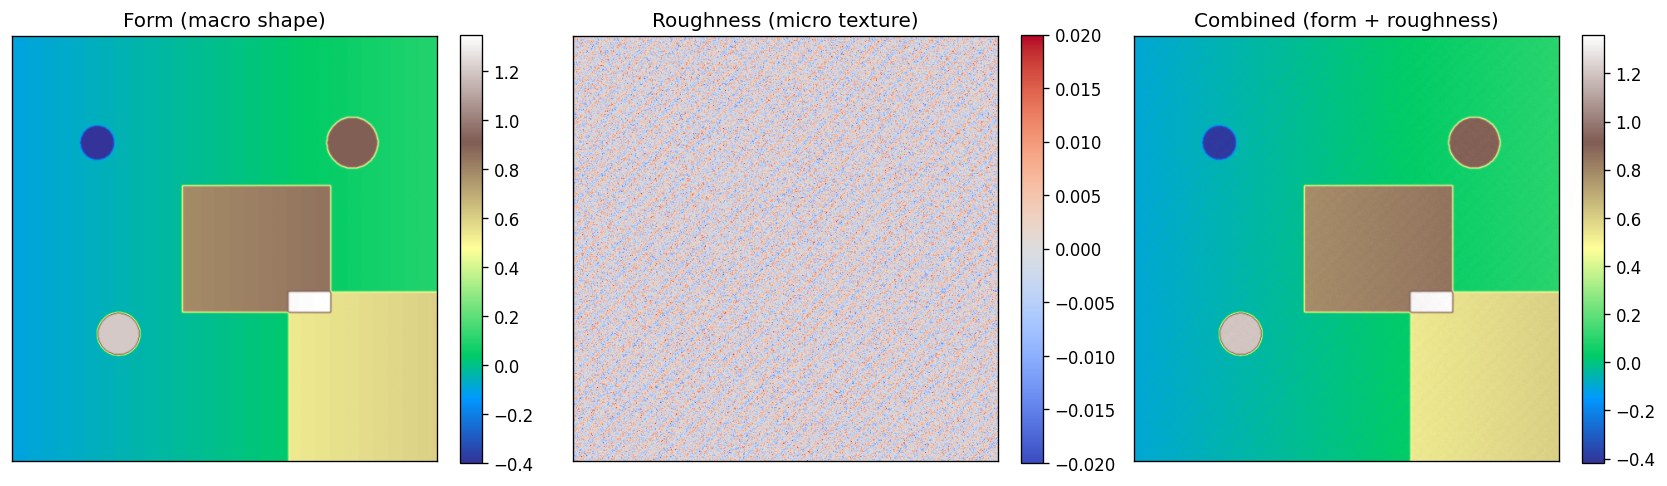

Surface height range: -0.4181 to 1.3610
True roughness Sa:    0.004316


In [3]:
form, roughness, combined = create_complex_surface(RESOLUTION)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(form, cmap='terrain')
axes[0].set_title('Form (macro shape)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(roughness, cmap='coolwarm', vmin=-0.02, vmax=0.02)
axes[1].set_title('Roughness (micro texture)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(combined, cmap='terrain')
axes[2].set_title('Combined (form + roughness)')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

true_sa = np.mean(np.abs(roughness - roughness.mean()))
print(f'Surface height range: {combined.min():.4f} to {combined.max():.4f}')
print(f'True roughness Sa:    {true_sa:.6f}')

## Animation 1: Reconstruction Builds Up with Each Scan

Each phase-shifted capture adds information. The N-step phase-shifting algorithm
requires at least 3 frames; additional frames improve noise rejection (SNR scales
as sqrt(N)) and suppress harmonic errors.

**Left panel**: the physical object with the projected fringe pattern (what the
camera sees). Each scan projects a different phase-shifted pattern.

**Right panel**: the 3D reconstruction that smoothly improves from noisy (3 scans)
to clean (12 scans).

In [4]:
import pyvista as pv
import imageio_ffmpeg

config = SimulationConfig(resolution=RESOLUTION, noise_level=NOISE)
source = SimulationSource(config)
source.set_surface(combined)

# Capture standard phase-shifted frames (used by later cells too)
patterns = generate_phase_sequence(RESOLUTION, period=SINGLE_PERIOD, n_steps=N_STEPS)
frames = []
for p in patterns:
    source.project_pattern(p)
    frames.append(source.capture_frame())

# --- Partial reconstructions: first k frames -> surface ---
eq_wl = SINGLE_PERIOD / SIMULATION_HEIGHT_SCALE

def reconstruct_from_k(k):
    """Phase extraction from first k of N_STEPS frames."""
    num = np.zeros(RESOLUTION, dtype=np.float64)
    den = np.zeros(RESOLUTION, dtype=np.float64)
    for i in range(k):
        delta = 2.0 * np.pi * i / N_STEPS
        num += frames[i] * np.sin(delta)
        den += frames[i] * np.cos(delta)
    wrapped = np.arctan2(num, den)
    unwrapped = unwrap_phase(wrapped)
    height = (eq_wl / (2 * np.pi)) * unwrapped
    h, w = height.shape
    yy, xx = np.mgrid[0:h, 0:w]
    A = np.column_stack([xx.ravel(), yy.ravel(), np.ones(h * w)])
    c = np.linalg.lstsq(A, height.ravel(), rcond=None)[0]
    return height - (c[0] * xx + c[1] * yy + c[2])

reconstructions = {k: reconstruct_from_k(k) for k in range(3, N_STEPS + 1)}

# True surface with plane removal (same coord frame as reconstructions)
true_surf = combined.copy()
_h, _w = true_surf.shape
_yy, _xx = np.mgrid[0:_h, 0:_w]
_A = np.column_stack([_xx.ravel(), _yy.ravel(), np.ones(_h * _w)])
_c = np.linalg.lstsq(_A, true_surf.ravel(), rcond=None)[0]
true_surf -= (_c[0] * _xx + _c[1] * _yy + _c[2])

# --- Grid setup ---
ds = 2
xs = np.arange(0, RESOLUTION[1], ds, dtype=np.float32)
ys = np.arange(0, RESOLUTION[0], ds, dtype=np.float32)
Xg, Yg = np.meshgrid(xs, ys)

final_surf = reconstructions[N_STEPS]
z_scale = RESOLUTION[1] * 0.3 / max(final_surf.max() - final_surf.min(), 1e-10)
vmax = np.abs(final_surf).max()

true_ds = true_surf[::ds, ::ds].astype(np.float32)
Z_true = true_ds * z_scale

# Camera (shared angles, each plotter has its own independent camera)
cx, cy = RESOLUTION[1] / 2, RESOLUTION[0] / 2
cdist, cz = RESOLUTION[1] * 1.8, RESOLUTION[1] * 0.5
a = np.radians(-45)
cam_pos = [(cx + cdist * np.cos(a), cy + cdist * np.sin(a), cz),
           (cx, cy, 0), (0, 0, 1)]

def smoothstep(x):
    x = np.clip(x, 0.0, 1.0)
    return x * x * (3.0 - 2.0 * x)

MORPH_FRAMES = 30
PANEL_W, PANEL_H = 480, 480
recon_keys = sorted(reconstructions.keys())

# Two independent plotters = independent cameras, no perspective coupling
pl_l = pv.Plotter(off_screen=True, window_size=(PANEL_W, PANEL_H))
pl_r = pv.Plotter(off_screen=True, window_size=(PANEL_W, PANEL_H))

vid = imageio_ffmpeg.write_frames(
    'anim1_reconstruction.mp4', (PANEL_W * 2, PANEL_H),
    fps=30, codec='libx264', pix_fmt_in='rgb24', pix_fmt_out='yuv420p',
    output_params=['-crf', '18'],
)
vid.send(None)  # prime

prev_h_ds = np.zeros_like(Xg)
prev_h_flat = prev_h_ds.flatten(order='F')
prev_fringe_flat = np.clip(
    frames[recon_keys[0] - 1][::ds, ::ds].flatten(order='F').astype(np.float32), 0, 1)

for ki, k in enumerate(recon_keys):
    curr_h_ds = reconstructions[k][::ds, ::ds].astype(np.float32)
    curr_h_flat = curr_h_ds.flatten(order='F')
    curr_fringe_flat = np.clip(
        frames[k - 1][::ds, ::ds].flatten(order='F').astype(np.float32), 0, 1)

    for f in range(MORPH_FRAMES):
        t = f / max(MORPH_FRAMES - 1, 1)
        t_s = smoothstep(t)

        # LEFT: true surface + fringe cross-fade
        fringe_val = (1.0 - t_s) * prev_fringe_flat + t_s * curr_fringe_flat
        pl_l.clear()
        grid_l = pv.StructuredGrid(Xg, Yg, Z_true)
        grid_l.point_data['intensity'] = fringe_val.astype(np.float32)
        pl_l.add_mesh(grid_l, scalars='intensity', cmap='gray', clim=[0, 1],
                      show_scalar_bar=False, lighting=False)
        pl_l.add_title(f'Scan {k}', font_size=12)
        pl_l.camera_position = cam_pos
        img_l = pl_l.screenshot(return_img=True)

        # RIGHT: reconstruction morph + height colormap
        Z_recon = ((1.0 - t_s) * prev_h_ds + t_s * curr_h_ds) * z_scale
        interp_flat = (1.0 - t_s) * prev_h_flat + t_s * curr_h_flat
        pl_r.clear()
        grid_r = pv.StructuredGrid(Xg, Yg, Z_recon)
        grid_r.point_data['height'] = interp_flat.astype(np.float32)
        pl_r.add_mesh(grid_r, scalars='height', cmap='viridis',
                      clim=[-vmax, vmax], show_scalar_bar=False,
                      smooth_shading=True)
        pl_r.add_title(f'Reconstruction ({k}/{N_STEPS})', font_size=12)
        pl_r.camera_position = cam_pos
        img_r = pl_r.screenshot(return_img=True)

        vid.send(np.hstack([img_l, img_r]).tobytes())

    prev_h_ds = curr_h_ds.copy()
    prev_h_flat = curr_h_flat.copy()
    prev_fringe_flat = curr_fringe_flat.copy()

vid.close()
pl_l.close()
pl_r.close()
Video('anim1_reconstruction.mp4')

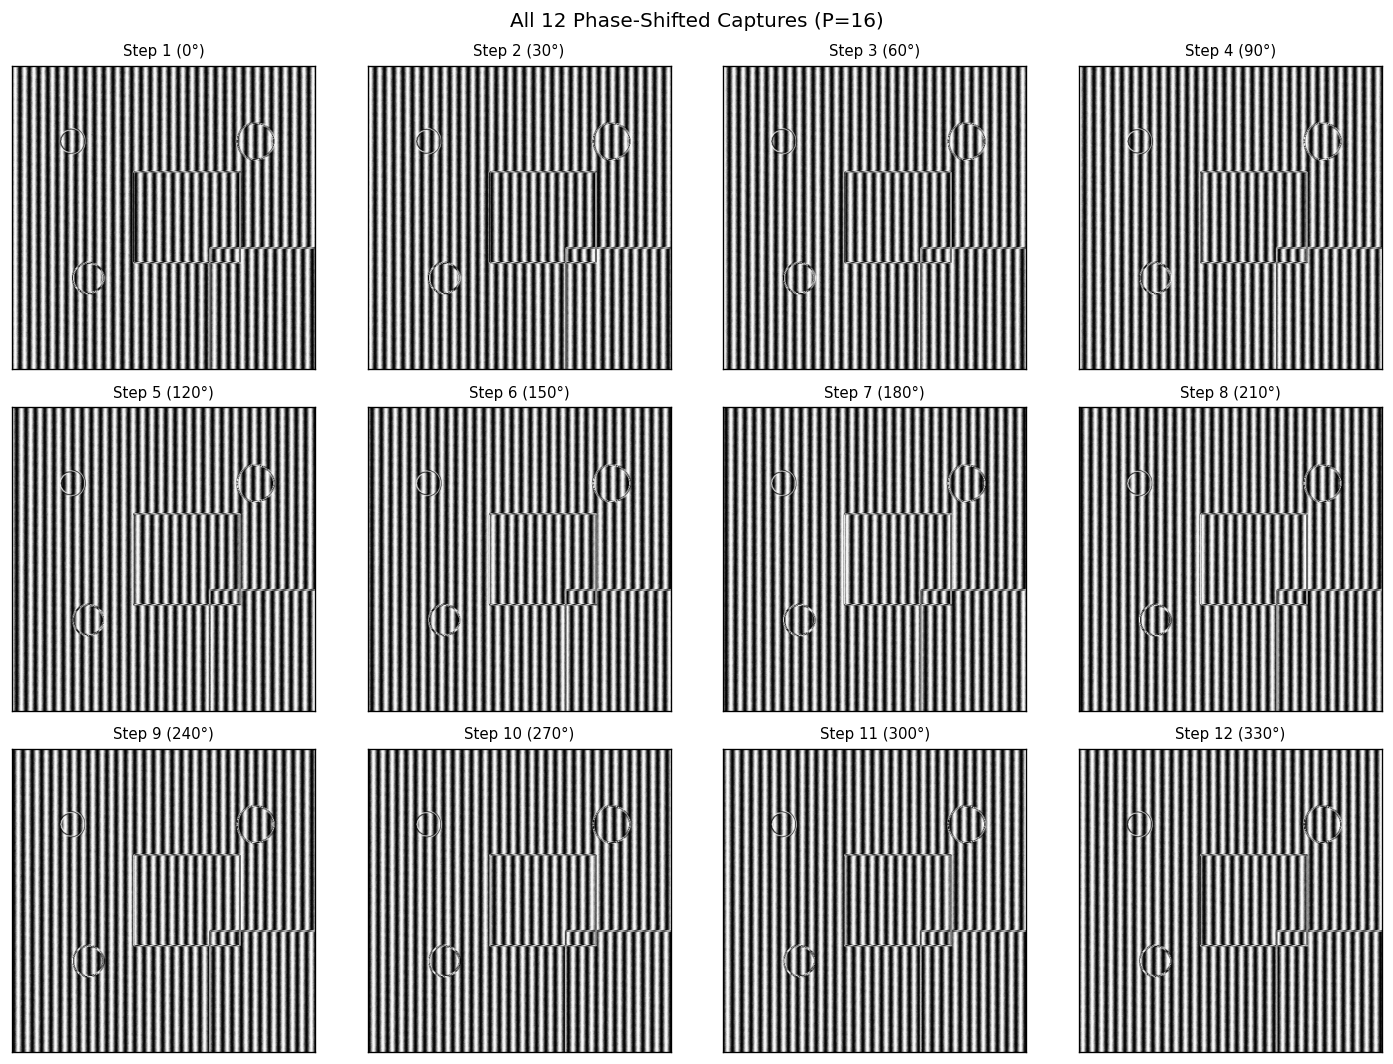

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(frames[i], cmap='gray', vmin=0, vmax=1)
    offset = 360 * i / N_STEPS
    ax.set_title(f'Step {i+1} ({offset:.0f}\u00b0)', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f'All {N_STEPS} Phase-Shifted Captures (P={SINGLE_PERIOD})', fontsize=12)
plt.tight_layout()
plt.show()

## Single-Frequency Measurement

With a single fringe period, phase unwrapping must be done **spatially**: the
algorithm propagates from pixel to pixel, accumulating 2pi jumps. At step
discontinuities that span multiple fringe periods, the unwrapper cannot distinguish
real height jumps from wrapping artifacts. These errors propagate outward from
the discontinuity, corrupting the entire downstream region.

In [6]:
single_phase = extract_phase(frames, n_steps=N_STEPS)
single_phase.unwrapped = unwrap_phase(single_phase.wrapped, single_phase.quality)

eq_wl_single = SINGLE_PERIOD / SIMULATION_HEIGHT_SCALE
calib_single = CalibrationParams(equivalent_wavelength=eq_wl_single, pixel_pitch=1.0)
single_height_map = phase_to_height(single_phase, calib_single)
single_height_map = remove_plane(single_height_map)
single_height = single_height_map.data

print(f'Equivalent wavelength: {eq_wl_single:.4f}')
print(f'Height range: {single_height.min():.4f} to {single_height.max():.4f}')

Equivalent wavelength: 0.3200
Height range: -0.8555 to 0.6886


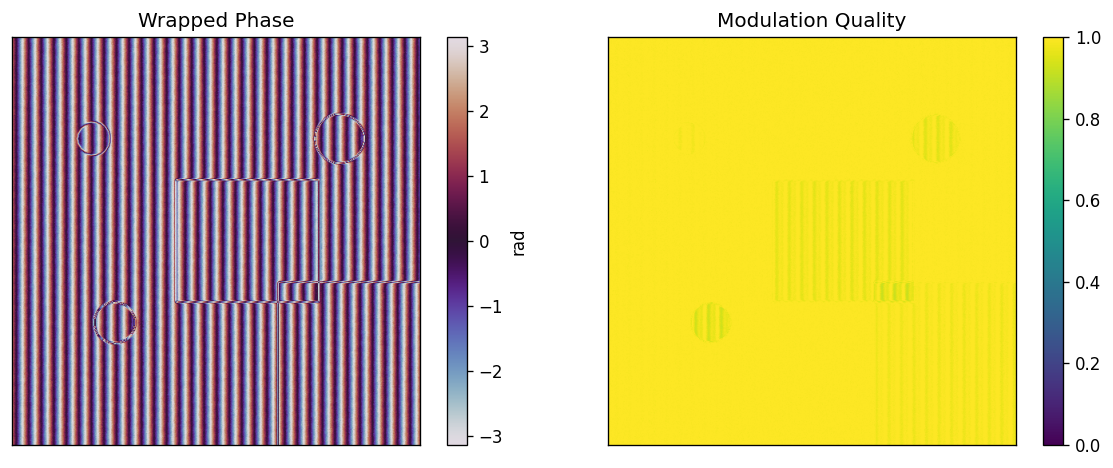

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(single_phase.wrapped, cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[0].set_title('Wrapped Phase')
plt.colorbar(im0, ax=axes[0], fraction=0.046, label='rad')

im1 = axes[1].imshow(single_phase.quality, cmap='viridis', vmin=0, vmax=1)
axes[1].set_title('Modulation Quality')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

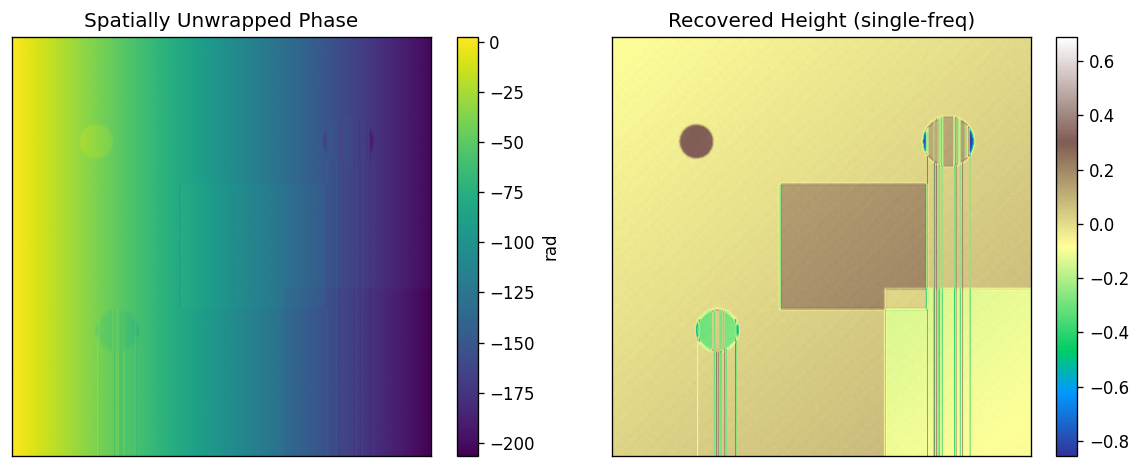

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(single_phase.unwrapped, cmap='viridis')
axes[0].set_title('Spatially Unwrapped Phase')
plt.colorbar(im0, ax=axes[0], fraction=0.046, label='rad')

im1 = axes[1].imshow(single_height, cmap='terrain')
axes[1].set_title('Recovered Height (single-freq)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

## Multi-Frequency Measurement

Multi-frequency temporal unwrapping uses three fringe periods (coarse to fine).
Each pixel is unwrapped independently by using the coarser frequency as a guide
for the finer one. This avoids spatial error propagation entirely.

**Critical: carrier removal before temporal unwrapping.** The PSA extracts
`-phi_true`, which includes both the carrier phase (from the projected fringe
spatial frequency) and the height-induced phase. The carrier `2*pi*x/P` causes
wrapping even at the coarsest frequency (P=256 on a 512px image = 2 full wraps).
We must remove the carrier to isolate the height-only phase, which at the coarsest
frequency is unambiguous (less than pi).

Sign convention: `height_phase = -(psa_output + carrier_phase)`

In [9]:
all_patterns = generate_multifreq_patterns(RESOLUTION, MULTI_PERIODS, N_STEPS)

wrapped_phases = []
quality_maps = []
raw_wrapped = []  # before carrier removal, for visualization

for i, freq_patterns in enumerate(all_patterns):
    freq_frames = []
    for p in freq_patterns:
        source.project_pattern(p)
        freq_frames.append(source.capture_frame())
    pm = extract_phase(freq_frames, n_steps=N_STEPS)
    raw_wrapped.append(pm.wrapped.copy())

    # Remove carrier: PSA gives -phi, so height_phase = -(wrapped + carrier)
    carrier = compute_carrier_phase(RESOLUTION, MULTI_PERIODS[i])
    height_phase = -(pm.wrapped + carrier)
    height_phase = np.arctan2(np.sin(height_phase), np.cos(height_phase))

    wrapped_phases.append(height_phase)
    quality_maps.append(pm.quality)

print(f'Captured {sum(len(p) for p in all_patterns)} total frames across {len(MULTI_PERIODS)} frequencies')

Captured 36 total frames across 3 frequencies


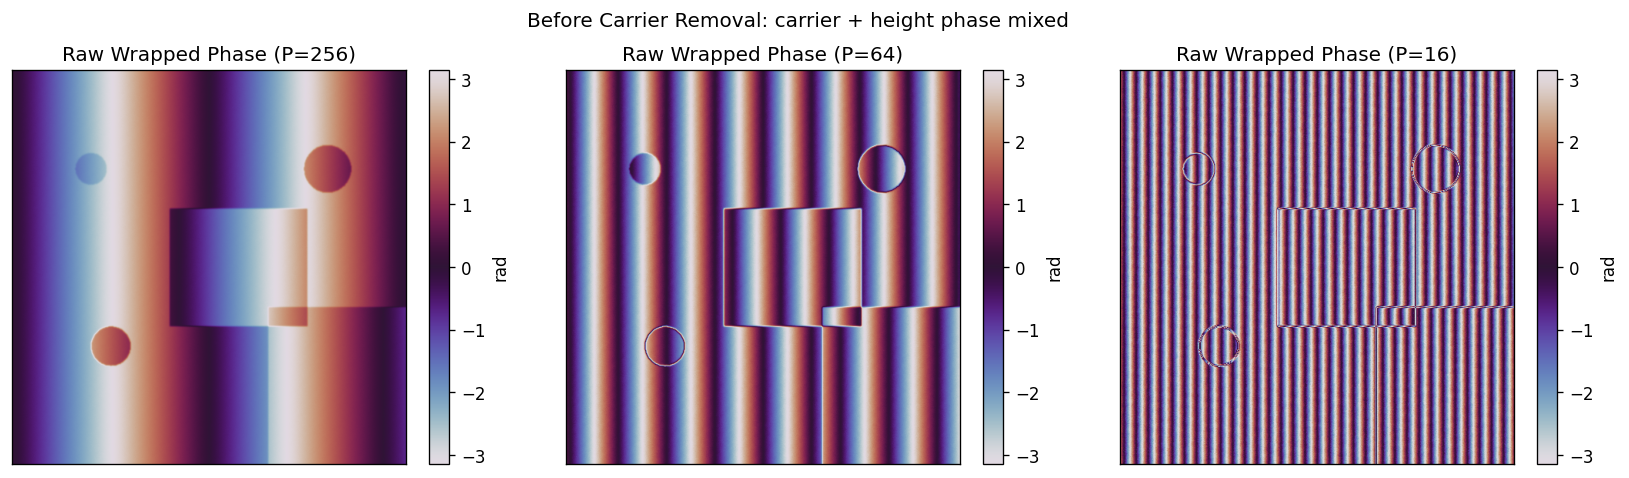

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (wp, period) in enumerate(zip(raw_wrapped, MULTI_PERIODS)):
    im = axes[i].imshow(wp, cmap='twilight', vmin=-np.pi, vmax=np.pi)
    axes[i].set_title(f'Raw Wrapped Phase (P={period})')
    axes[i].set_xticks([]); axes[i].set_yticks([])
    plt.colorbar(im, ax=axes[i], fraction=0.046, label='rad')
plt.suptitle('Before Carrier Removal: carrier + height phase mixed', fontsize=12)
plt.tight_layout()
plt.show()

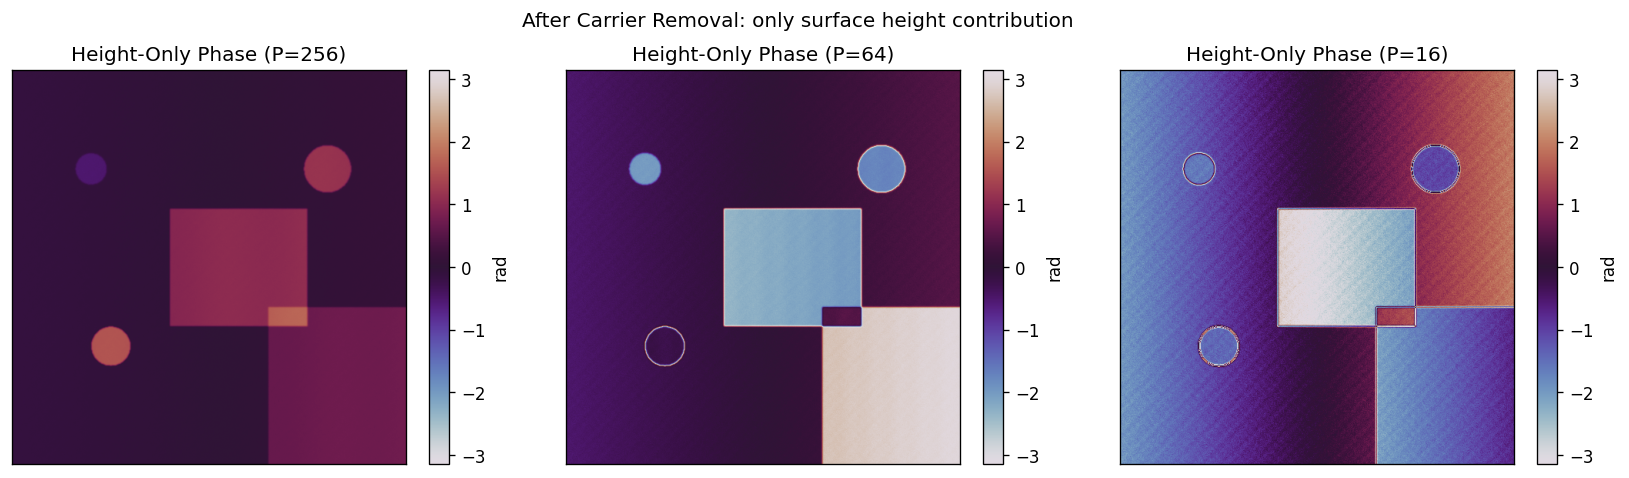

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (hp, period) in enumerate(zip(wrapped_phases, MULTI_PERIODS)):
    im = axes[i].imshow(hp, cmap='twilight', vmin=-np.pi, vmax=np.pi)
    axes[i].set_title(f'Height-Only Phase (P={period})')
    axes[i].set_xticks([]); axes[i].set_yticks([])
    plt.colorbar(im, ax=axes[i], fraction=0.046, label='rad')
plt.suptitle('After Carrier Removal: only surface height contribution', fontsize=12)
plt.tight_layout()
plt.show()

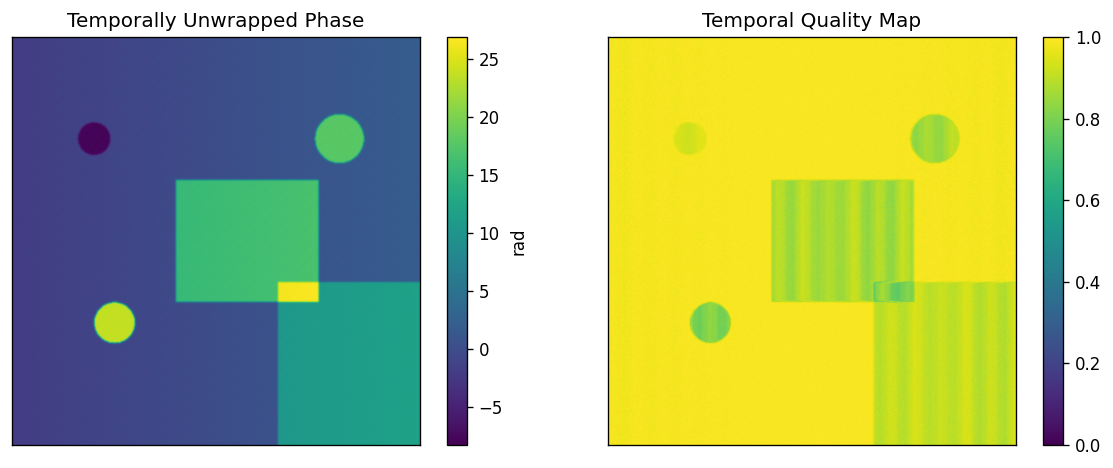

Equivalent wavelength: 0.3200
Height range: -0.4212 to 1.3698
Quality: min=0.7309, mean=0.9621


In [12]:
multi_unwrapped, multi_quality = temporal_unwrap(wrapped_phases, MULTI_PERIODS)

finest_period = MULTI_PERIODS[-1]
eq_wl_multi = finest_period / SIMULATION_HEIGHT_SCALE
combined_pm = PhaseMap(wrapped=multi_unwrapped, unwrapped=multi_unwrapped, quality=multi_quality)
calib_multi = CalibrationParams(equivalent_wavelength=eq_wl_multi, pixel_pitch=1.0)
multi_height_map = phase_to_height(combined_pm, calib_multi)
multi_height = multi_height_map.data

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(multi_unwrapped, cmap='viridis')
axes[0].set_title('Temporally Unwrapped Phase')
plt.colorbar(im0, ax=axes[0], fraction=0.046, label='rad')
im1 = axes[1].imshow(multi_quality, cmap='viridis', vmin=0, vmax=1)
axes[1].set_title('Temporal Quality Map')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f'Equivalent wavelength: {eq_wl_multi:.4f}')
print(f'Height range: {multi_height.min():.4f} to {multi_height.max():.4f}')
print(f'Quality: min={multi_quality.min():.4f}, mean={multi_quality.mean():.4f}')

## Animation 2: Multi-Frequency Adds Detail

Temporal unwrapping uses progressively finer fringe periods. Each frequency
stage captures 12 scans, and the coarser result guides the finer one.

**Left panel**: the object with fringes at each frequency -- wide fringes at
P=256, progressively denser at P=64 and P=16.

**Right panel**: the reconstruction smoothly gaining resolution:

1. **P=256** (coarsest): Overall shape resolved with low detail.
2. **P=64** (medium): Step features and plateaus become distinct.
3. **P=16** (finest): Full surface detail with micrometer-scale roughness.

In [13]:
# Compute intermediate unwrapping stages
stages = []
stage_labels = []

# Stage 1: Coarsest only (P=256) - assumed unambiguous
stages.append(wrapped_phases[0].copy())
stage_labels.append(f'P = {MULTI_PERIODS[0]}  (12 scans)')

# Stage 2: Coarse guides P=64
current = wrapped_phases[0].copy()
fine_wp = wrapped_phases[1]
ratio = MULTI_PERIODS[0] / MULTI_PERIODS[1]
scaled = current * ratio
k = np.round((scaled - fine_wp) / (2 * np.pi))
stage2 = fine_wp + k * 2 * np.pi
stages.append(stage2)
stage_labels.append(f'P = {MULTI_PERIODS[1]}  (24 scans)')

# Stage 3: P=64 guides P=16 (final)
fine_wp2 = wrapped_phases[2]
ratio2 = MULTI_PERIODS[1] / MULTI_PERIODS[2]
scaled2 = stage2 * ratio2
k2 = np.round((scaled2 - fine_wp2) / (2 * np.pi))
stage3 = fine_wp2 + k2 * 2 * np.pi
stages.append(stage3)
stage_labels.append(f'P = {MULTI_PERIODS[2]}  (36 scans)')

# Convert each stage to height
stage_heights = []
for i, s in enumerate(stages):
    p = MULTI_PERIODS[i]
    eq = p / SIMULATION_HEIGHT_SCALE
    pm_s = PhaseMap(wrapped=s, unwrapped=s, quality=np.ones_like(s))
    calib_s = CalibrationParams(equivalent_wavelength=eq, pixel_pitch=1.0)
    hm_s = phase_to_height(pm_s, calib_s)
    stage_heights.append(hm_s.data)

# Get one representative captured frame per frequency
freq_frames = []
for fp in all_patterns:
    source.project_pattern(fp[0])
    freq_frames.append(source.capture_frame())

# --- Two independent plotters, stitched side-by-side ---
ds = 2
xs = np.arange(0, RESOLUTION[1], ds, dtype=np.float32)
ys = np.arange(0, RESOLUTION[0], ds, dtype=np.float32)
Xg, Yg = np.meshgrid(xs, ys)

final_h = stage_heights[-1]
z_scale = RESOLUTION[1] * 0.3 / max(final_h.max() - final_h.min(), 1e-10)
vmax = np.abs(final_h).max()

true_ds_mf = true_surf[::ds, ::ds].astype(np.float32)
Z_true_mf = true_ds_mf * z_scale

cx, cy = RESOLUTION[1] / 2, RESOLUTION[0] / 2
cdist, cz = RESOLUTION[1] * 1.8, RESOLUTION[1] * 0.5
a = np.radians(-45)
cam_pos = [(cx + cdist * np.cos(a), cy + cdist * np.sin(a), cz),
           (cx, cy, 0), (0, 0, 1)]

def smoothstep(x):
    x = np.clip(x, 0.0, 1.0)
    return x * x * (3.0 - 2.0 * x)

MORPH_FRAMES = 90
PANEL_W, PANEL_H = 480, 480

pl_l = pv.Plotter(off_screen=True, window_size=(PANEL_W, PANEL_H))
pl_r = pv.Plotter(off_screen=True, window_size=(PANEL_W, PANEL_H))

vid = imageio_ffmpeg.write_frames(
    'anim2_multifreq.mp4', (PANEL_W * 2, PANEL_H),
    fps=30, codec='libx264', pix_fmt_in='rgb24', pix_fmt_out='yuv420p',
    output_params=['-crf', '18'],
)
vid.send(None)

prev_h_ds = np.zeros_like(Xg)
prev_h_flat = prev_h_ds.flatten(order='F')
prev_fringe_flat = np.clip(
    freq_frames[0][::ds, ::ds].flatten(order='F').astype(np.float32), 0, 1)

for si, (sh, label) in enumerate(zip(stage_heights, stage_labels)):
    curr_h_ds = sh[::ds, ::ds].astype(np.float32)
    curr_h_flat = curr_h_ds.flatten(order='F')
    curr_fringe_flat = np.clip(
        freq_frames[si][::ds, ::ds].flatten(order='F').astype(np.float32), 0, 1)

    for f in range(MORPH_FRAMES):
        t = f / max(MORPH_FRAMES - 1, 1)
        t_s = smoothstep(t)

        # LEFT: true surface + fringe cross-fade
        fringe_val = (1.0 - t_s) * prev_fringe_flat + t_s * curr_fringe_flat
        pl_l.clear()
        grid_l = pv.StructuredGrid(Xg, Yg, Z_true_mf)
        grid_l.point_data['intensity'] = fringe_val.astype(np.float32)
        pl_l.add_mesh(grid_l, scalars='intensity', cmap='gray', clim=[0, 1],
                      show_scalar_bar=False, lighting=False)
        pl_l.add_title(label, font_size=12)
        pl_l.camera_position = cam_pos
        img_l = pl_l.screenshot(return_img=True)

        # RIGHT: reconstruction morph + height colormap
        Z_recon = ((1.0 - t_s) * prev_h_ds + t_s * curr_h_ds) * z_scale
        interp_flat = (1.0 - t_s) * prev_h_flat + t_s * curr_h_flat
        pl_r.clear()
        grid_r = pv.StructuredGrid(Xg, Yg, Z_recon)
        grid_r.point_data['height'] = interp_flat.astype(np.float32)
        pl_r.add_mesh(grid_r, scalars='height', cmap='viridis',
                      clim=[-vmax, vmax], show_scalar_bar=False,
                      smooth_shading=True)
        pl_r.add_title('Reconstruction', font_size=12)
        pl_r.camera_position = cam_pos
        img_r = pl_r.screenshot(return_img=True)

        vid.send(np.hstack([img_l, img_r]).tobytes())

    prev_h_ds = curr_h_ds.copy()
    prev_h_flat = curr_h_flat.copy()
    prev_fringe_flat = curr_fringe_flat.copy()

vid.close()
pl_l.close()
pl_r.close()
Video('anim2_multifreq.mp4')

## Roughness Comparison

To compare roughness recovery, we separate form from roughness using a
**morphological filter** (robust at step edges, unlike Gaussian which rings).
The cutoff wavelength divides macro-scale form from micro-scale roughness.

Quality masking excludes pixels where the multi-frequency temporal quality
falls below the threshold, and MAD-based outlier removal cleans residual spikes.
The ground truth is masked identically for a fair comparison.

In [14]:
def extract_roughness_from_height(height_data, cutoff, method):
    """Remove form, return roughness."""
    hm = HeightMap(data=height_data, unit='um', pixel_pitch=1.0,
                   equivalent_wavelength=1.0)
    analysis = separate_surface(hm, cutoff_wavelength=cutoff, method=method)
    return analysis.finish.data

def apply_quality_mask(rough, quality, threshold):
    """NaN out low-quality pixels."""
    masked = rough.copy()
    masked[quality < threshold] = np.nan
    return masked

def remove_outliers(rough, sigma=5.0):
    """Remove outlier spikes using MAD."""
    valid = rough[~np.isnan(rough)]
    if len(valid) == 0:
        return rough
    median = np.median(valid)
    mad = np.median(np.abs(valid - median))
    robust_std = 1.4826 * mad
    limit = sigma * robust_std
    cleaned = rough.copy()
    cleaned[np.abs(rough - median) > limit] = np.nan
    return cleaned

single_rough = extract_roughness_from_height(single_height, CUTOFF, FORM_METHOD)
multi_rough = extract_roughness_from_height(multi_height, CUTOFF, FORM_METHOD)

# Quality masking + outlier removal on multi-freq
multi_rough_masked = apply_quality_mask(multi_rough, multi_quality, QUALITY_THRESHOLD)
multi_rough_masked = remove_outliers(multi_rough_masked)

# Mask ground truth identically for fair comparison
true_rough_masked = roughness.copy()
true_rough_masked[multi_quality < QUALITY_THRESHOLD] = np.nan
true_rough_masked[np.isnan(multi_rough_masked)] = np.nan

n_masked = np.isnan(multi_rough_masked).sum()
print(f'Roughness extracted with {FORM_METHOD} form removal (cutoff={CUTOFF})')
print(f'Total masked pixels: {n_masked:,} / {multi_rough_masked.size:,} ({100*n_masked/multi_rough_masked.size:.1f}%)')

Roughness extracted with morphological form removal (cutoff=50.0)
Total masked pixels: 45 / 262,144 (0.0%)


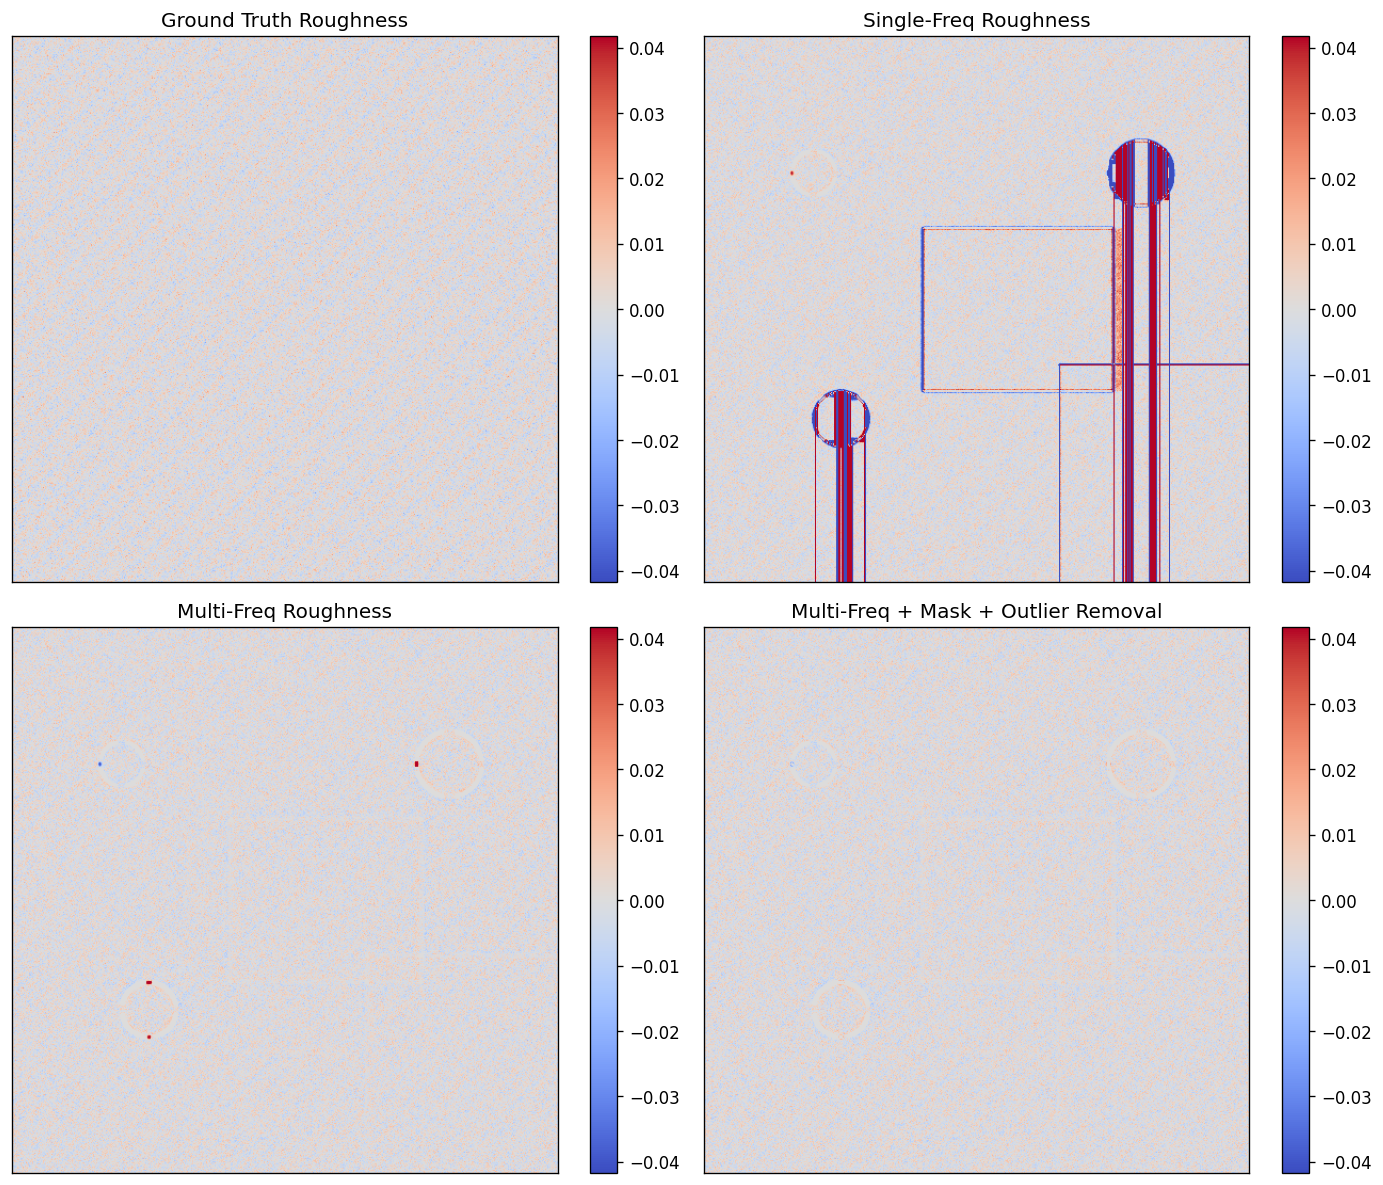

In [15]:
rough_p99 = np.nanpercentile(np.abs(roughness), 99)
vlim = rough_p99 * 3.0

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

im00 = axes[0,0].imshow(roughness, cmap='coolwarm', vmin=-vlim, vmax=vlim)
axes[0,0].set_title('Ground Truth Roughness')
plt.colorbar(im00, ax=axes[0,0], fraction=0.046)

im01 = axes[0,1].imshow(np.clip(single_rough, -vlim, vlim), cmap='coolwarm', vmin=-vlim, vmax=vlim)
axes[0,1].set_title('Single-Freq Roughness')
plt.colorbar(im01, ax=axes[0,1], fraction=0.046)

im10 = axes[1,0].imshow(np.clip(multi_rough, -vlim, vlim), cmap='coolwarm', vmin=-vlim, vmax=vlim)
axes[1,0].set_title('Multi-Freq Roughness')
plt.colorbar(im10, ax=axes[1,0], fraction=0.046)

disp_masked = np.clip(np.nan_to_num(multi_rough_masked, nan=0.0), -vlim, vlim)
im11 = axes[1,1].imshow(disp_masked, cmap='coolwarm', vmin=-vlim, vmax=vlim)
axes[1,1].set_title('Multi-Freq + Mask + Outlier Removal')
plt.colorbar(im11, ax=axes[1,1], fraction=0.046)

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

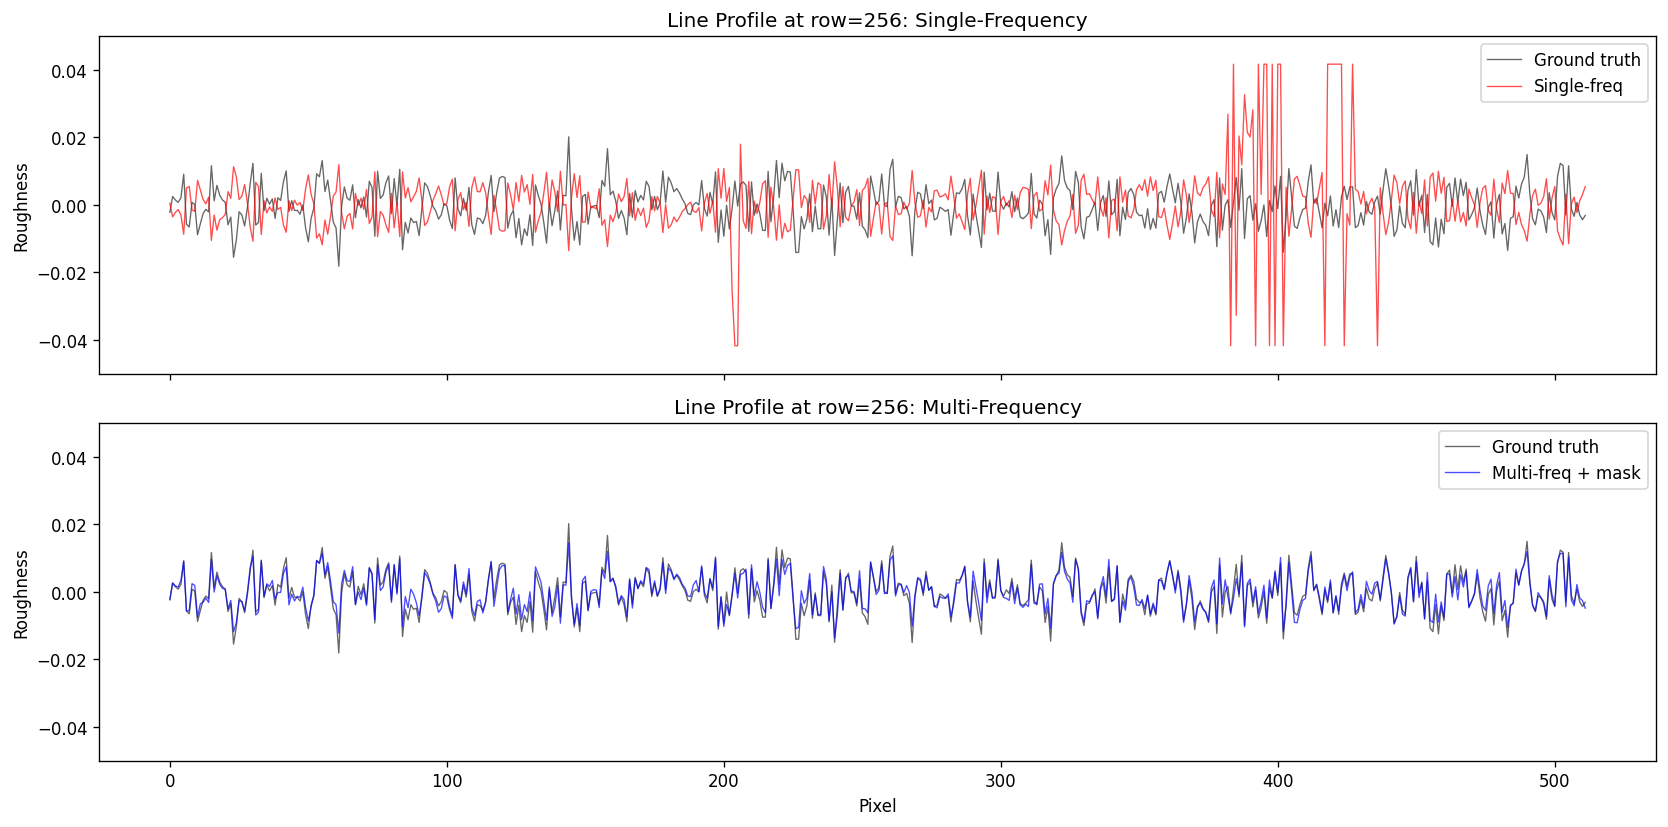

In [16]:
row = RESOLUTION[0] // 2

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
x_px = np.arange(RESOLUTION[1])

axes[0].plot(x_px, roughness[row], 'k-', alpha=0.6, label='Ground truth', linewidth=0.8)
axes[0].plot(x_px, np.clip(single_rough[row], -vlim, vlim), 'r-', alpha=0.7, label='Single-freq', linewidth=0.8)
axes[0].set_ylabel('Roughness')
axes[0].set_title(f'Line Profile at row={row}: Single-Frequency')
axes[0].legend()
axes[0].set_ylim(-vlim * 1.2, vlim * 1.2)

axes[1].plot(x_px, roughness[row], 'k-', alpha=0.6, label='Ground truth', linewidth=0.8)
multi_row = np.nan_to_num(multi_rough_masked[row], nan=0.0)
axes[1].plot(x_px, np.clip(multi_row, -vlim, vlim), 'b-', alpha=0.7, label='Multi-freq + mask', linewidth=0.8)
axes[1].set_ylabel('Roughness')
axes[1].set_xlabel('Pixel')
axes[1].set_title(f'Line Profile at row={row}: Multi-Frequency')
axes[1].legend()
axes[1].set_ylim(-vlim * 1.2, vlim * 1.2)

plt.tight_layout()
plt.show()

In [17]:
def compute_errors(rec_roughness, true_roughness):
    """Compute Sa, Sq, Sz with error percentages."""
    rec_hm = HeightMap(data=rec_roughness, unit='um', pixel_pitch=1.0, equivalent_wavelength=1.0)
    true_hm = HeightMap(data=true_roughness, unit='um', pixel_pitch=1.0, equivalent_wavelength=1.0)
    rec_p = compute_roughness_parameters(rec_hm)
    true_p = compute_roughness_parameters(true_hm)
    rows = []
    for key in ('Sa', 'Sq', 'Sz'):
        tv, rv = true_p[key], rec_p[key]
        err = abs(rv - tv) / (tv + 1e-12) * 100
        rows.append((key, tv, rv, err))
    return rows

single_err = compute_errors(single_rough, roughness)
multi_err = compute_errors(multi_rough_masked, true_rough_masked)

print(f'{"Param":<6} {"True":>10} {"Single":>10} {"Multi+Mask":>10}  {"S.Err%":>8} {"M.Err%":>8}')
print('-' * 65)
for i in range(3):
    key = single_err[i][0]
    tv = single_err[i][1]
    sv = single_err[i][2]
    mv = multi_err[i][2]
    se = single_err[i][3]
    me = multi_err[i][3]
    print(f'{key:<6} {tv:>10.6f} {sv:>10.6f} {mv:>10.6f}  {se:>7.1f}% {me:>7.1f}%')

Param        True     Single Multi+Mask    S.Err%   M.Err%
-----------------------------------------------------------------
Sa       0.004316   0.013849   0.004088    220.9%     5.3%
Sq       0.005412   0.042849   0.004996    691.7%     7.7%
Sz       0.051903   0.830191   0.045182   1499.5%    13.0%


## All Surfaces Summary

Run the full single-freq and multi-freq pipelines on all three test surfaces
(smooth, simple step, complex) to compare roughness accuracy across geometries.

In [18]:
surfaces = [
    ('Smooth', create_smooth_surface(RESOLUTION)),
    ('Simple Step', create_simple_step_surface(RESOLUTION)),
    ('Complex', create_complex_surface(RESOLUTION)),
]

all_results = []

for name, (frm, rgh, comb) in surfaces:
    src = SimulationSource(SimulationConfig(resolution=RESOLUTION, noise_level=NOISE))
    src.set_surface(comb)

    # Single-freq
    pats = generate_phase_sequence(RESOLUTION, period=SINGLE_PERIOD, n_steps=N_STEPS)
    frs = []
    for p in pats:
        src.project_pattern(p)
        frs.append(src.capture_frame())
    spm = extract_phase(frs, n_steps=N_STEPS)
    spm.unwrapped = unwrap_phase(spm.wrapped, spm.quality)
    eq_s = SINGLE_PERIOD / SIMULATION_HEIGHT_SCALE
    shm = phase_to_height(spm, CalibrationParams(equivalent_wavelength=eq_s, pixel_pitch=1.0))
    shm = remove_plane(shm)
    sh = shm.data

    # Multi-freq with carrier removal
    ap = generate_multifreq_patterns(RESOLUTION, MULTI_PERIODS, N_STEPS)
    wps = []
    qms = []
    for fi, fp in enumerate(ap):
        frs2 = []
        for p in fp:
            src.project_pattern(p)
            frs2.append(src.capture_frame())
        pm2 = extract_phase(frs2, n_steps=N_STEPS)
        carrier = compute_carrier_phase(RESOLUTION, MULTI_PERIODS[fi])
        hp = -(pm2.wrapped + carrier)
        hp = np.arctan2(np.sin(hp), np.cos(hp))
        wps.append(hp)
        qms.append(pm2.quality)

    mu, mq = temporal_unwrap(wps, MULTI_PERIODS)
    eq_m = MULTI_PERIODS[-1] / SIMULATION_HEIGHT_SCALE
    mpm = PhaseMap(wrapped=mu, unwrapped=mu, quality=mq)
    mhm = phase_to_height(mpm, CalibrationParams(equivalent_wavelength=eq_m, pixel_pitch=1.0))
    mh = mhm.data

    # Roughness
    sr = extract_roughness_from_height(sh, CUTOFF, FORM_METHOD)
    mr = extract_roughness_from_height(mh, CUTOFF, FORM_METHOD)
    mrm = apply_quality_mask(mr, mq, QUALITY_THRESHOLD)
    mrm = remove_outliers(mrm)
    trm = rgh.copy()
    trm[mq < QUALITY_THRESHOLD] = np.nan
    trm[np.isnan(mrm)] = np.nan

    se = compute_errors(sr, rgh)
    me = compute_errors(mrm, trm)
    all_results.append((name, se, me))

# Summary table
print(f'{"Surface":<15} {"Sa(Single)":>10} {"Sa(Multi)":>10}  {"Sq(Single)":>10} {"Sq(Multi)":>10}')
print('-' * 65)
for name, se, me in all_results:
    print(f'{name:<15} {se[0][3]:>9.1f}% {me[0][3]:>9.1f}%  {se[1][3]:>9.1f}% {me[1][3]:>9.1f}%')
print('\nLower % = better roughness recovery')

Surface         Sa(Single)  Sa(Multi)  Sq(Single)  Sq(Multi)
-----------------------------------------------------------------
Smooth                5.8%       6.0%        9.1%       9.2%
Simple Step           3.2%       4.4%        3.7%       7.0%
Complex             220.9%       5.3%      691.7%       7.7%

Lower % = better roughness recovery


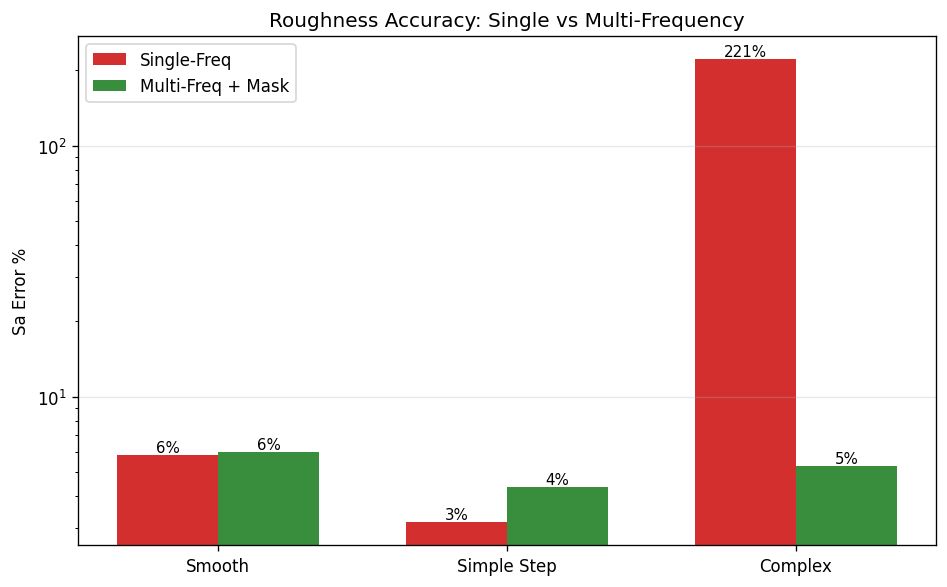

In [19]:
surface_names = [r[0] for r in all_results]
single_sa = [r[1][0][3] for r in all_results]
multi_sa = [r[2][0][3] for r in all_results]

x = np.arange(len(surface_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, single_sa, width, label='Single-Freq', color='#d32f2f')
bars2 = ax.bar(x + width/2, multi_sa, width, label='Multi-Freq + Mask', color='#388e3c')

ax.set_ylabel('Sa Error %')
ax.set_title('Roughness Accuracy: Single vs Multi-Frequency')
ax.set_xticks(x)
ax.set_xticklabels(surface_names)
ax.legend()
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)

# Annotate bars
for bar, val in zip(bars1, single_sa):
    ax.annotate(f'{val:.0f}%', xy=(bar.get_x() + bar.get_width()/2, val),
                ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, multi_sa):
    ax.annotate(f'{val:.0f}%', xy=(bar.get_x() + bar.get_width()/2, val),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()